# Magnetometer and Interplanetary Magentic Field Strength
This data was optained from the DSCOVR data download linked [here](https://www.ngdc.noaa.gov/dscovr/portal/index.html#/download/1743638400000;1743983999999). The specific datasets in this notebook are the May 8th 2024 mg1: DSCOVR Magnetometer Level 1 and the May 10th 2024 m1m: DSCOVR Magnetometer Level 2 One Minute Averages. The file size for the mg1 file is a lot larger than the m1m, so in the future it would be better to work with the m1m magnetometer data.

In [2]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

## May 8th Data

In [3]:
# load data from DSCOVR Magnetometer Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_8/oe_m1m_dscovr_s20240508000000_e20240508235959_p20240509021546_pub.nc')
magnetometer_variables = ['bx_gsm', 'by_gsm', 'bz_gsm', 'bt']
mag_ds8 = ds_raw[magnetometer_variables]

In [4]:
ds_raw

<xarray.Dataset> Size: 94kB
Dimensions:                   (time: 1440)
Coordinates:
  * time                      (time) datetime64[ns] 12kB 2024-05-08 ... 2024-...
Data variables: (12/23)
    sample_count              (time) int16 3kB 2900 2900 3000 ... 2850 2700 2794
    measurement_mode          (time) int8 1kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    measurement_range         (time) int8 1kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    bt                        (time) float32 6kB 4.13 4.16 4.13 ... 1.91 1.7
    bx_gse                    (time) float32 6kB -2.83 -2.92 ... -1.84 -1.63
    by_gse                    (time) float32 6kB 2.23 2.41 2.44 ... 0.43 0.38
    ...                        ...
    fill_flag                 (time) int8 1kB 0 0 0 0 0 1 1 0 ... 0 0 0 0 0 0 0
    possible_saturation_flag  (time) int8 1kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    calibration_mode_flag     (time) int8 1kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    maneuver_flag             (time) int8 1kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    low_sample_count_flag     (time) int8 1kB 0 0 0 0 0 1 1 0 ... 0 0 0 0 0 0 0
    overall_quality           (time) int8 1kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes: (12/42)
    Conventions:                    ACDD-1.3, Spase v2.2.3
    title:                          DSCOVR Magnetometer Level 2 One Minute Av...
    id:                             oe_m1m_dscovr_s20240508000000_e2024050823...
    naming_authority:               gov.noaa.swpc
    program:                        DSCOVR
    summary:                        Interplanetary magnetic field observation...
    ...                             ...
    publisher_url:                  http://www.ngdc.noaa.gov/dscovr/
    records_maximum:                1440
    records_present:                1440
    records_data:                   1432
    records_fill:                   8
    records_missing:                0

In [5]:
# load data from DSCOVR Faraday Cup Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_8/oe_f1m_dscovr_s20240508000000_e20240508235959_p20240509022123_pub.nc')
farraday_variables = ['proton_speed', 'proton_density', 'proton_temperature', 'alpha_speed', 'alpha_density', 'alpha_temperature']
far_ds8 = ds_raw[farraday_variables]

In [6]:
# load data from Spacecraft ephemeris - this is all space craft positioning and velocity data
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_8/oe_pop_dscovr_s20240508000000_e20240508235959_p20240509022156_pub.nc')

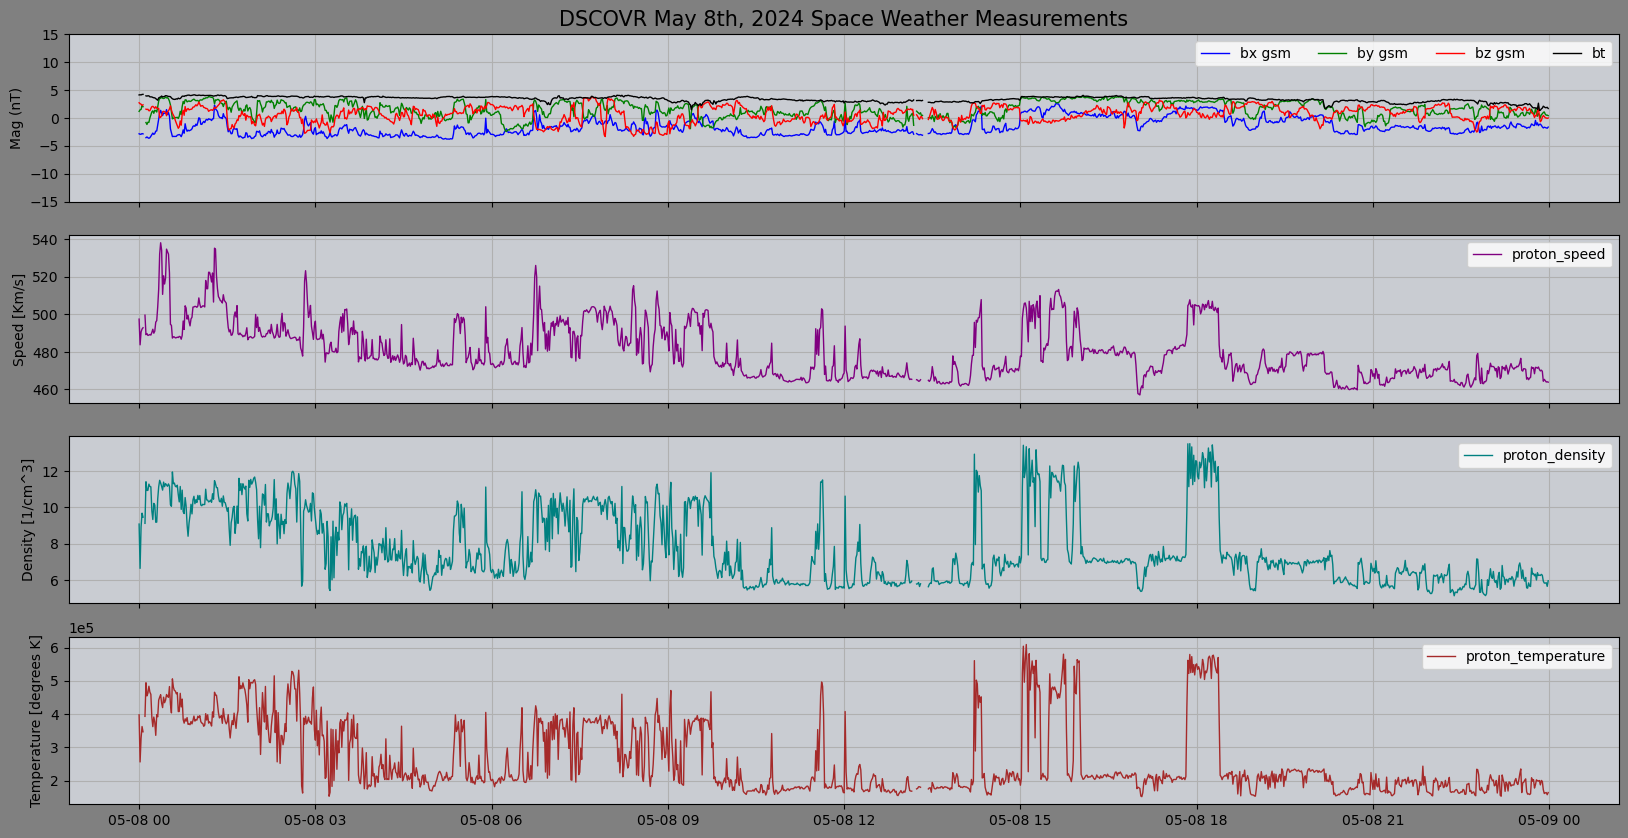

In [7]:
fig, ax = plt.subplots(4, 1, figsize=(20,10), sharex='col', facecolor='grey')
ax1, ax2, ax3, ax4 = ax

### Magnetometer data
# time series plot for bx_gsm
ax1.plot(mag_ds8.time, mag_ds8.bx_gsm, linewidth=1, color='b', label='bx gsm')
ax1.set_title('DSCOVR May 8th, 2024 Space Weather Measurements', fontsize=15)
ax1.set_ylabel('Mag (nT)')
# time series plot for by_gsm
ax1.plot(mag_ds8.time, mag_ds8.by_gsm, linewidth=1, color='g', label='by gsm')
# time series plot for bz_gsm
ax1.plot(mag_ds8.time, mag_ds8.bz_gsm, linewidth=1, color='r', label='bz gsm')
# time series plot for bt
ax1.plot(mag_ds8.time, mag_ds8.bt, linewidth=1, color='k', label='bt')
ax1.set_ylim(-15, 15)
#plt.xlim(05-08 00, 05-09-00)
ax1.legend(loc='upper right', ncol=4)
ax1.grid()
ax1.set_facecolor('#dce0e7cc')

### Farraday data
# time series plot for proton speed
ax2.plot(far_ds8.time, far_ds8.proton_speed, linewidth=1, color='purple', label='proton_speed')
ax2.set_ylabel('Speed [Km/s]')
ax2.legend()
ax2.grid()
ax2.set_facecolor('#dce0e7cc')
# time series plot for proton_density
ax3.plot(far_ds8.time, far_ds8.proton_density, linewidth=1, color='teal', label='proton_density')
ax3.set_ylabel('Density [1/cm^3]')
ax3.legend()
ax3.grid()
ax3.set_facecolor('#dce0e7cc')
# time series plot for proton_temperature
ax4.plot(far_ds8.time, far_ds8.proton_temperature, linewidth=1, color='brown', label='proton_temperature')
ax4.set_ylabel('Temperature [degrees K]')
ax4.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax4.legend()
ax4.grid()
ax4.set_facecolor('#dce0e7cc')

plt.show()

## May 9th Data

In [8]:
# load data from DSCOVR Magnetometer Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_9/oe_m1m_dscovr_s20240509000000_e20240509235959_p20240511021629_pub.nc')
magnetometer_variables = ['bx_gsm', 'by_gsm', 'bz_gsm', 'bt']
mag_ds9 = ds_raw[magnetometer_variables]

# load data from DSCOVR Faraday Cup Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_9/oe_f1m_dscovr_s20240509000000_e20240509235959_p20240511022214_pub.nc')
farraday_variables = ['proton_speed', 'proton_density', 'proton_temperature', 'alpha_speed', 'alpha_density', 'alpha_temperature']
far_ds9 = ds_raw[farraday_variables]

In [10]:
far_ds9

<xarray.Dataset> Size: 46kB
Dimensions:             (time: 1440)
Coordinates:
  * time                (time) datetime64[ns] 12kB 2024-05-09 ... 2024-05-09T...
Data variables:
    proton_speed        (time) float32 6kB 464.8 463.9 463.7 ... 417.0 418.3
    proton_density      (time) float32 6kB 5.94 5.98 5.93 ... 5.47 5.79 5.79
    proton_temperature  (time) float32 6kB 1.587e+05 1.652e+05 ... 6.66e+04
    alpha_speed         (time) float32 6kB nan nan nan nan ... nan nan nan nan
    alpha_density       (time) float32 6kB nan nan nan nan ... nan nan nan nan
    alpha_temperature   (time) float32 6kB nan nan nan nan ... nan nan nan nan
Attributes: (12/41)
    Conventions:                   ACDD-1.3, Spase v2.2.3
    title:                         DSCOVR Faraday Cup Level 2 One Minute Aver...
    id:                            oe_f1m_dscovr_s20240509000000_e20240509235...
    naming_authority:              gov.noaa.swpc
    program:                       DSCOVR
    summary:                       Solar wind observations collected from Far...
    ...                            ...
    publisher_url:                 http://www.ngdc.noaa.gov/dscovr/
    records_maximum:               1440
    records_present:               1440
    records_data:                  1440
    records_fill:                  0
    records_missing:               0

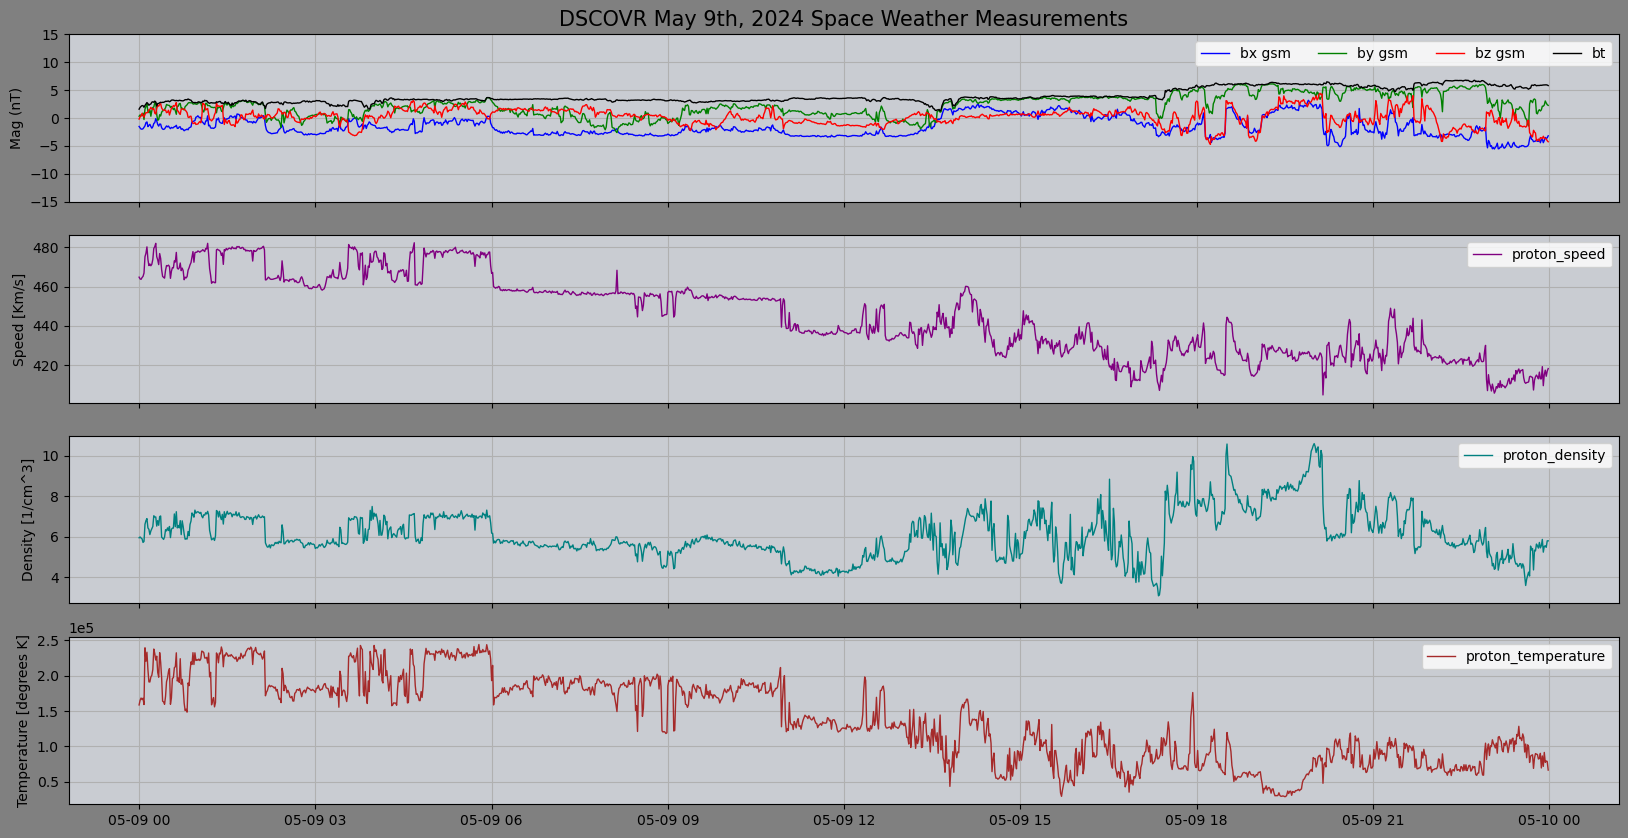

In [9]:
fig, ax = plt.subplots(4, 1, figsize=(20,10), sharex='col', facecolor='grey')
ax1, ax2, ax3, ax4 = ax

### Magnetometer data
# time series plot for bx_gsm
ax1.plot(mag_ds9.time, mag_ds9.bx_gsm, linewidth=1, color='b', label='bx gsm')
ax1.set_title('DSCOVR May 9th, 2024 Space Weather Measurements', fontsize=15)
ax1.set_ylabel('Mag (nT)')
# time series plot for by_gsm
ax1.plot(mag_ds9.time, mag_ds9.by_gsm, linewidth=1, color='g', label='by gsm')
# time series plot for bz_gsm
ax1.plot(mag_ds9.time, mag_ds9.bz_gsm, linewidth=1, color='r', label='bz gsm')
# time series plot for bt
ax1.plot(mag_ds9.time, mag_ds9.bt, linewidth=1, color='k', label='bt')
ax1.set_ylim(-15, 15)
#plt.xlim(05-08 00, 05-09-00)
ax1.legend(loc='upper right', ncol=4)
ax1.grid()
ax1.set_facecolor('#dce0e7cc')

### Farraday data
# time series plot for proton speed
ax2.plot(far_ds9.time, far_ds9.proton_speed, linewidth=1, color='purple', label='proton_speed')
ax2.set_ylabel('Speed [Km/s]')
ax2.legend()
ax2.grid()
ax2.set_facecolor('#dce0e7cc')
# time series plot for proton_density
ax3.plot(far_ds9.time, far_ds9.proton_density, linewidth=1, color='teal', label='proton_density')
ax3.set_ylabel('Density [1/cm^3]')
ax3.legend()
ax3.grid()
ax3.set_facecolor('#dce0e7cc')
# time series plot for proton_temperature
ax4.plot(far_ds9.time, far_ds9.proton_temperature, linewidth=1, color='brown', label='proton_temperature')
ax4.set_ylabel('Temperature [degrees K]')
ax4.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax4.legend()
ax4.grid()
ax4.set_facecolor('#dce0e7cc')

plt.show()

## May 10th Data

In [71]:
# load data from DSCOVR Magnetometer Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_10/oe_m1m_dscovr_s20240510000000_e20240510235959_p20240511034031_pub.nc')
magnetometer_variables = ['bx_gsm', 'by_gsm', 'bz_gsm', 'bt']
mag_ds10 = ds_raw[magnetometer_variables]

# load data from DSCOVR Faraday Cup Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_10/oe_f1m_dscovr_s20240510000000_e20240510235959_p20240511034609_pub.nc')
farraday_variables = ['proton_speed', 'proton_density', 'proton_temperature', 'alpha_speed', 'alpha_density', 'alpha_temperature']
far_ds10 = ds_raw[farraday_variables]

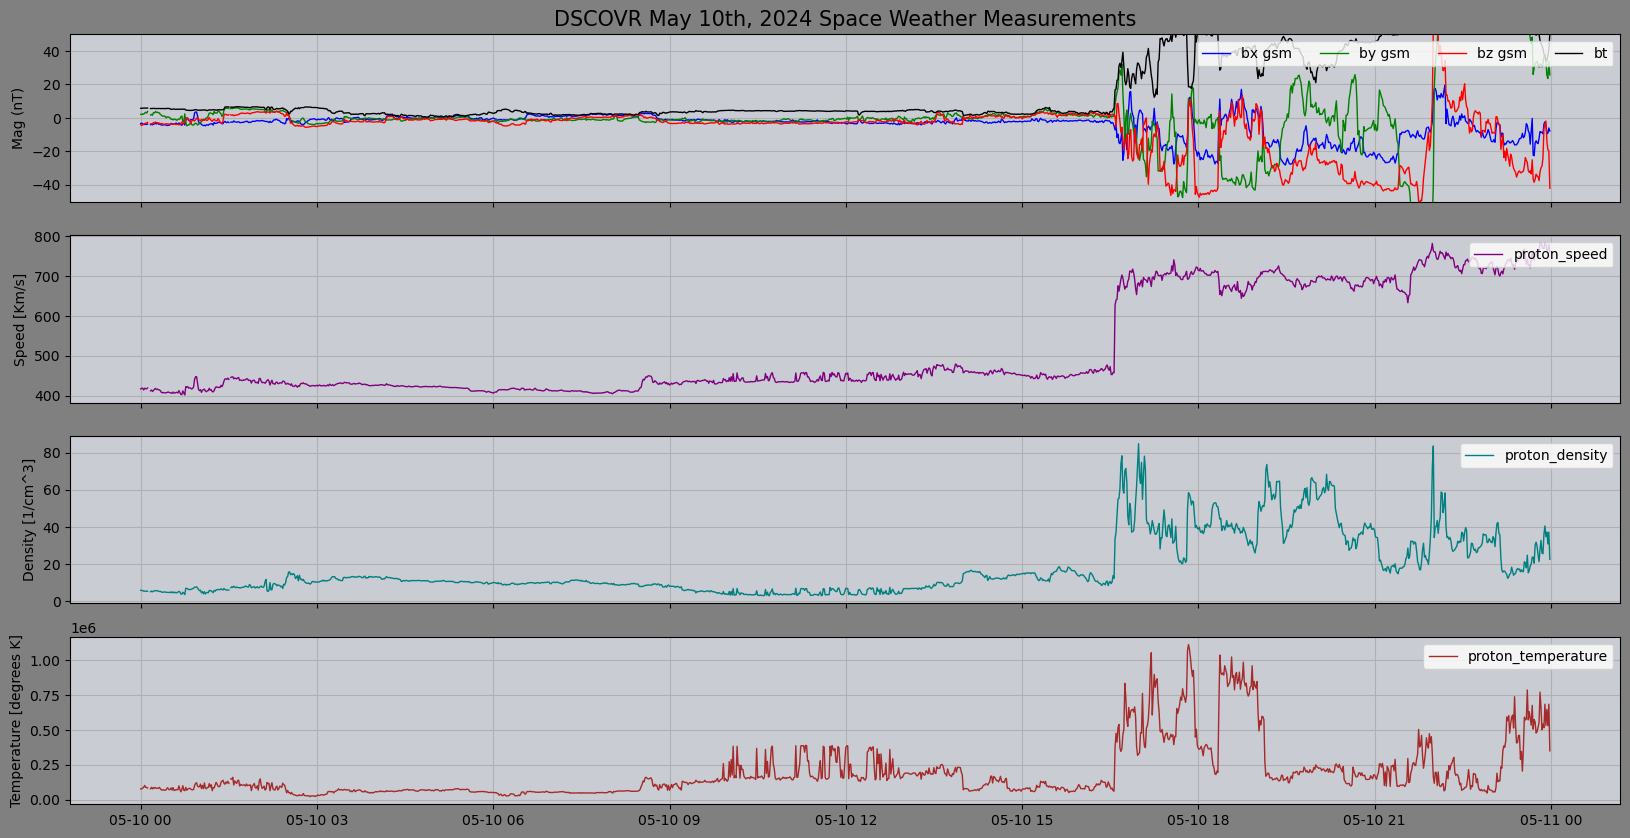

In [84]:
fig, ax = plt.subplots(4, 1, figsize=(20,10), sharex='col', facecolor='grey')
ax1, ax2, ax3, ax4 = ax

### Magnetometer data
# time series plot for bx_gsm
ax1.plot(mag_ds10.time, mag_ds10.bx_gsm, linewidth=1, color='b', label='bx gsm')
ax1.set_title('DSCOVR May 10th, 2024 Space Weather Measurements', fontsize=15)
ax1.set_ylabel('Mag (nT)')
# time series plot for by_gsm
ax1.plot(mag_ds10.time, mag_ds10.by_gsm, linewidth=1, color='green', label='by gsm')
# time series plot for bz_gsm
ax1.plot(mag_ds10.time, mag_ds10.bz_gsm, linewidth=1, color='r', label='bz gsm')
# time series plot for bt
ax1.plot(mag_ds10.time, mag_ds10.bt, linewidth=1, color='k', label='bt')
ax1.set_ylim(-50, 50)
ax1.legend(loc='upper right', ncol=4)
ax1.grid()
ax1.set_facecolor('#dce0e7cc')

### Farraday data
# time series plot for proton speed
ax2.plot(far_ds10.time, far_ds10.proton_speed, linewidth=1, color='purple', label='proton_speed')
ax2.set_ylabel('Speed [Km/s]')
ax2.legend()
ax2.grid()
ax2.set_facecolor('#dce0e7cc')
ax2.legend(loc='upper right', ncol=4)
# time series plot for proton_density
ax3.plot(far_ds10.time, far_ds10.proton_density, linewidth=1, color='teal', label='proton_density')
ax3.set_ylabel('Density [1/cm^3]')
ax3.legend()
ax3.grid()
ax3.set_facecolor('#dce0e7cc')
# time series plot for proton_temperature
ax4.plot(far_ds10.time, far_ds10.proton_temperature, linewidth=1, color='brown', label='proton_temperature')
ax4.set_ylabel('Temperature [degrees K]')
ax4.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax4.legend()
ax4.grid()
ax4.set_facecolor('#dce0e7cc')

plt.show()

## May 11th Data

In [73]:
# load data from DSCOVR Magnetometer Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_11/oe_m1m_dscovr_s20240511000000_e20240511235959_p20240512021629_pub.nc')
magnetometer_variables = ['bx_gsm', 'by_gsm', 'bz_gsm', 'bt']
mag_ds11 = ds_raw[magnetometer_variables]

# load data from DSCOVR Faraday Cup Level 2 One Minute Averages
ds_raw = xr.load_dataset('../data/DSCOVR_data/may_11/oe_f1m_dscovr_s20240511000000_e20240511235959_p20240512022214_pub.nc')
farraday_variables = ['proton_speed', 'proton_density', 'proton_temperature', 'alpha_speed', 'alpha_density', 'alpha_temperature']
far_ds11 = ds_raw[farraday_variables]

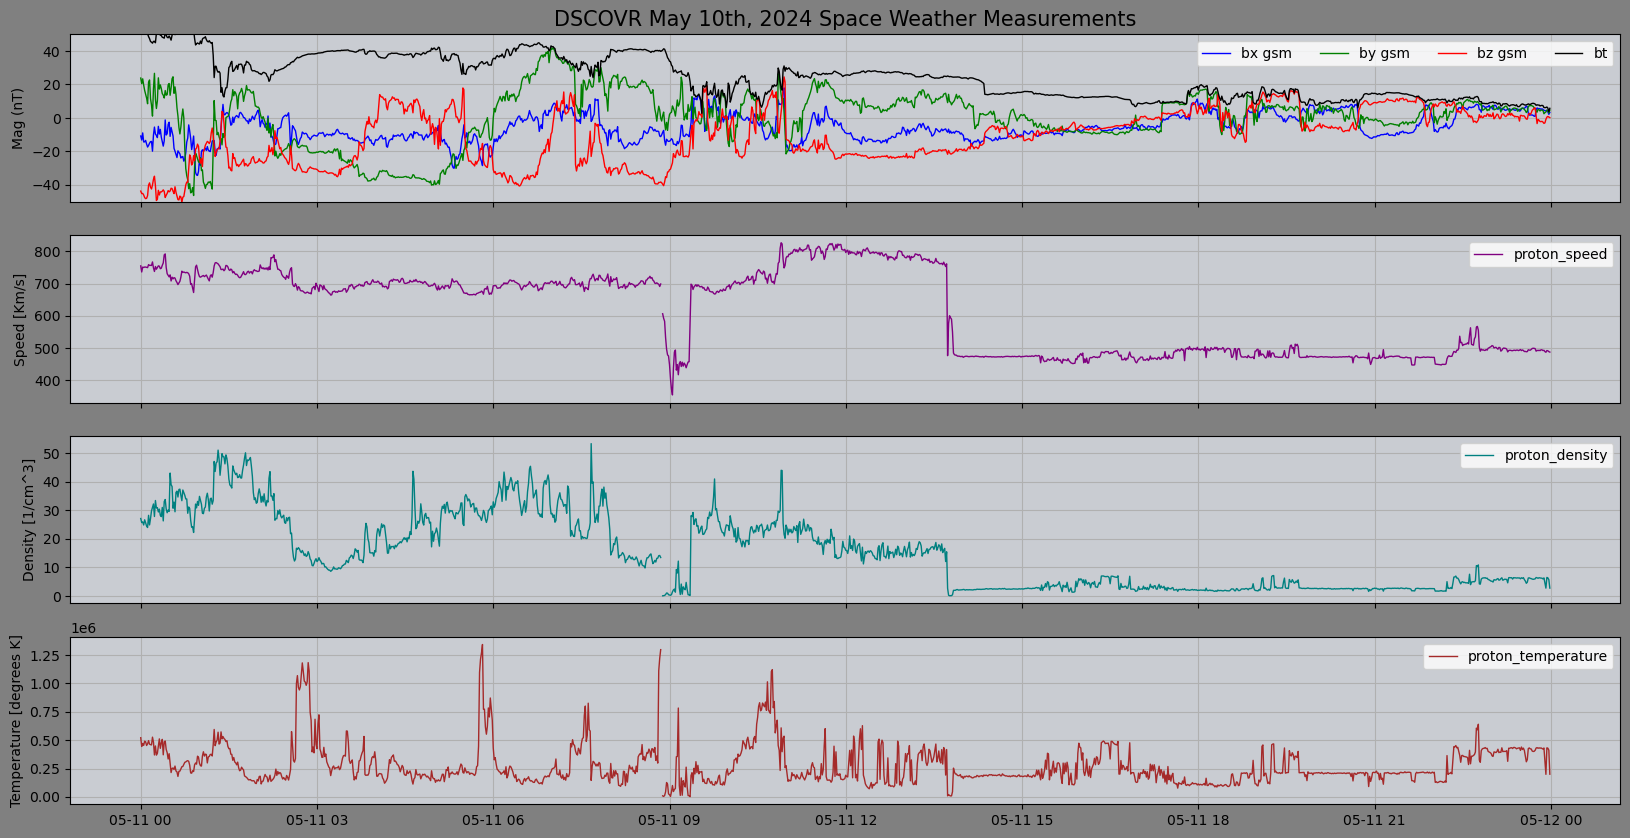

In [85]:
fig, ax = plt.subplots(4, 1, figsize=(20,10), sharex='col', facecolor='grey')
ax1, ax2, ax3, ax4 = ax

### Magnetometer data
# time series plot for bx_gsm
ax1.plot(mag_ds11.time, mag_ds11.bx_gsm, linewidth=1, color='b', label='bx gsm')
ax1.set_title('DSCOVR May 10th, 2024 Space Weather Measurements', fontsize=15)
ax1.set_ylabel('Mag (nT)')
# time series plot for by_gsm
ax1.plot(mag_ds11.time, mag_ds11.by_gsm, linewidth=1, color='g', label='by gsm')
# time series plot for bz_gsm
ax1.plot(mag_ds11.time, mag_ds11.bz_gsm, linewidth=1, color='r', label='bz gsm')
# time series plot for bt
ax1.plot(mag_ds11.time, mag_ds11.bt, linewidth=1, color='k', label='bt')
ax1.set_ylim(-50, 50)
ax1.legend(loc='upper right', ncol=4)
ax1.grid()
ax1.set_facecolor('#dce0e7cc')

### Farraday data
# time series plot for proton speed
ax2.plot(far_ds11.time, far_ds11.proton_speed, linewidth=1, color='purple', label='proton_speed')
ax2.set_ylabel('Speed [Km/s]')
ax2.legend()
ax2.grid()
ax2.set_facecolor('#dce0e7cc')
# time series plot for proton_density
ax3.plot(far_ds11.time, far_ds11.proton_density, linewidth=1, color='teal', label='proton_density')
ax3.set_ylabel('Density [1/cm^3]')
ax3.legend()
ax3.grid()
ax3.set_facecolor('#dce0e7cc')
# time series plot for proton_temperature
ax4.plot(far_ds11.time, far_ds11.proton_temperature, linewidth=1, color='brown', label='proton_temperature')
ax4.set_ylabel('Temperature [degrees K]')
ax4.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax4.legend()
ax4.grid()
ax4.set_facecolor('#dce0e7cc')

plt.show()

In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

In [2]:
# mg1: DSCOVR Magnetometer Level 1 for may 8th
ds_raw = xr.load_dataset('../data/DSCOVR_data/oe_mg1_dscovr_s20240508000000_e20240508235959_p20240509013658_pub.nc')
magnetometer_variables = ['bx_gsm', 'by_gsm', 'bz_gsm']
mag_ds = ds_raw[magnetometer_variables]

In [3]:
mag_ds

<xarray.Dataset> Size: 83MB
Dimensions:  (time: 4169036)
Coordinates:
  * time     (time) datetime64[ns] 33MB 2024-05-08T00:00:00.008000 ... 2024-0...
Data variables:
    bx_gsm   (time) float32 17MB -2.28 -2.365 -2.39 ... -1.472 -1.456 -1.459
    by_gsm   (time) float32 17MB 2.44 2.46 2.483 2.484 ... 0.3444 0.3382 0.3679
    bz_gsm   (time) float32 17MB 2.32 2.263 2.356 ... -0.2809 -0.2956 -0.312
Attributes: (12/40)
    Conventions:                    ACDD-1.3, Spase v2.2.3
    title:                          DSCOVR Magnetometer Level 1
    id:                             oe_mg1_dscovr_s20240508000000_e2024050823...
    naming_authority:               gov.noaa.swpc
    program:                        DSCOVR
    summary:                        Interplanetary magnetic field observation...
    ...                             ...
    publisher_institution:          DOC/NOAA/NESDIS/NGDC
    publisher_email:                william.rowland@noaa.gov
    publisher_url:                  http://www.ngdc.noaa.gov/dscovr/
    records_maximum:                4320000
    records_present:                4169036
    records_data:                   4169036

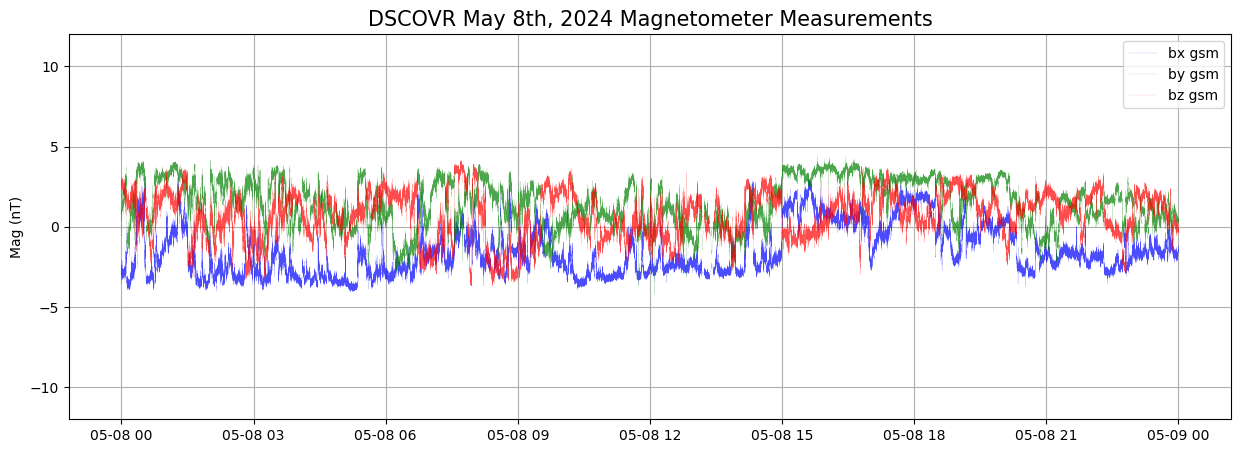

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(15,5))
ax1 = axes

# time series plot for bx_gsm
ax1.plot(mag_ds.time, mag_ds.bx_gsm, linewidth=0.1, color='b', alpha=0.7, label='bx gsm')
ax1.set_title('DSCOVR May 8th, 2024 Magnetometer Measurements', fontsize=15)
ax1.set_ylabel('Mag (nT)')

# time series plot for by_gsm
#ax2 = ax1.twiny()
ax1.plot(mag_ds.time, mag_ds.by_gsm, linewidth=0.1, color='g', alpha=0.7, label='by gsm')

# time series plot for bz_gsm
#ax3 = ax1.twiny()
ax1.plot(mag_ds.time, mag_ds.bz_gsm, linewidth=0.1, color='r', alpha=0.7, label='bz gsm')

plt.ylim(-12, 12)
#plt.xlim(05-08 00, 05-09-00)
plt.legend()
plt.grid()

plt.show()

In [8]:
# m1m: DSCOVR Magnetometer Level 2 One Minute Averages May 10th
ds_raw = xr.load_dataset('../data/DSCOVR_data/oe_m1m_dscovr_s20240510000000_e20240510235959_p20240511034031_pub.nc')
magnetometer_variables = ['bx_gsm', 'by_gsm', 'bz_gsm']
mag_ds10 = ds_raw[magnetometer_variables]

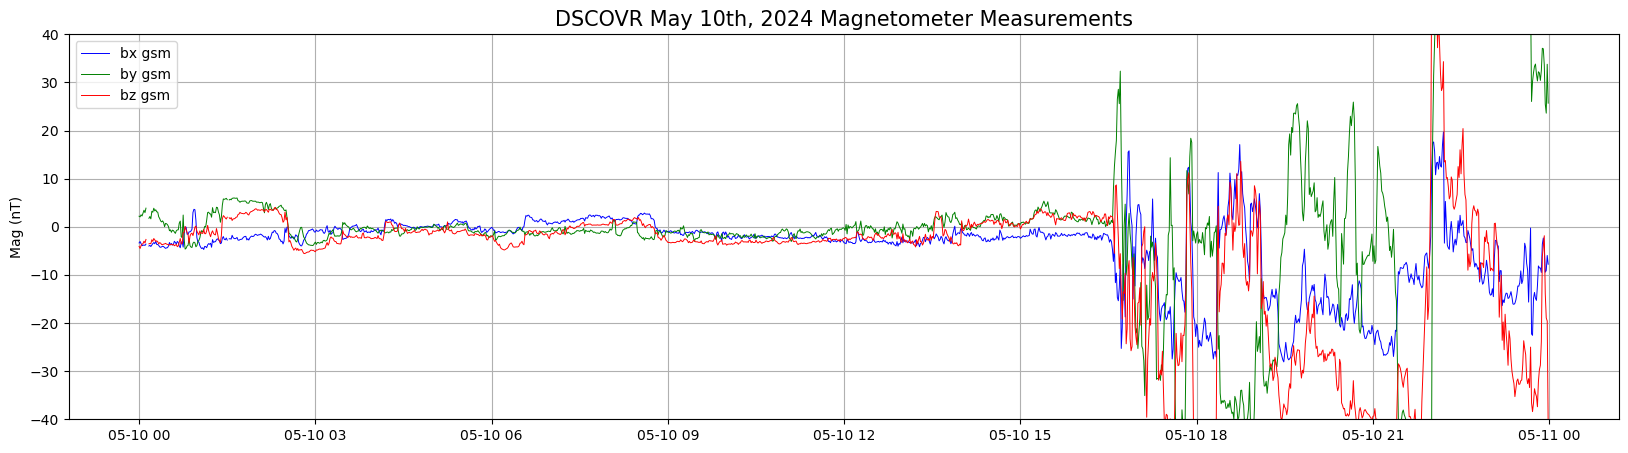

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(20,5))
ax1 = axes

# time series plot for bx_gsm
ax1.plot(mag_ds10.time, mag_ds10.bx_gsm, linewidth=0.7, color='b', label='bx gsm')
ax1.set_title('DSCOVR May 10th, 2024 Magnetometer Measurements', fontsize=15)
ax1.set_ylabel('Mag (nT)')

# time series plot for by_gsm
#ax2 = ax1.twiny()
ax1.plot(mag_ds10.time, mag_ds10.by_gsm, linewidth=0.7, color='g', label='by gsm')

# time series plot for bz_gsm
#ax3 = ax1.twiny()
ax1.plot(mag_ds10.time, mag_ds10.bz_gsm, linewidth=0.7, color='r', label='bz gsm')

plt.ylim(-40, 40)
#plt.xlim(05-08 00, 05-09-00)
plt.legend()
plt.grid()

plt.show()

In [ ]:
#